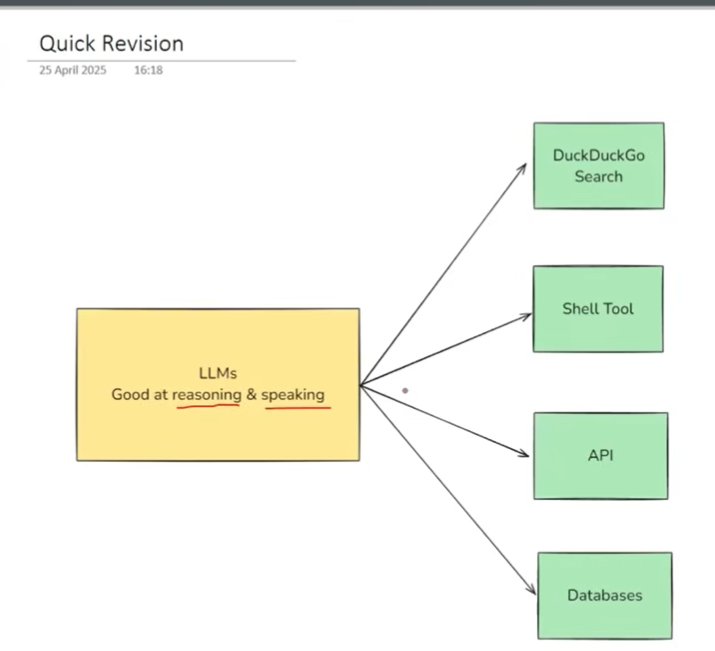
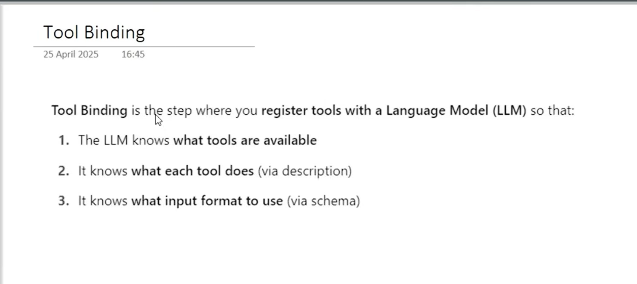

In [1]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
import requests

c:\Users\Sikandar\miniconda3\envs\myvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#tool create
@tool
def multiply(a: int, b: int) -> int:
    """Given 2 numbers a and b Multiplies two numbers."""
    return a * b
print(multiply.invoke({"a": 2, "b": 3}))  # Output: 6

6


In [3]:
multiply.name, multiply.description, multiply.args_schema

('multiply',
 'Given 2 numbers a and b Multiplies two numbers.',
 langchain_core.utils.pydantic.multiply)

In [4]:
llm = ChatOpenAI()
llm_with_tools= llm.bind_tools([multiply])

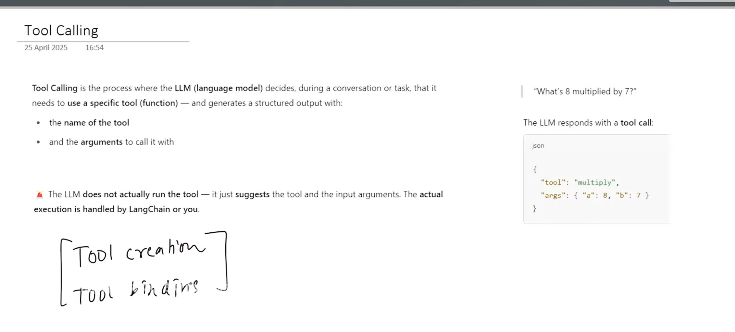

In [5]:
llm_with_tools.invoke("hi how are you"
)

AIMessage(content="I'm just a computer program, so I don't have feelings, but I'm here and ready to help you with any questions or tasks you have. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 57, 'total_tokens': 96, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DDuCV1yWDWv9vGsTCPEoz2prd75yV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019c9fbf-c6b7-7352-9aaa-e2d43c71ad87-0', usage_metadata={'input_tokens': 57, 'output_tokens': 39, 'total_tokens': 96, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [6]:
result = llm_with_tools.invoke(
    "can you multiply 2 with 4"
)
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_OQSolOB8qaVy2LOCmMMdQFqP', 'function': {'arguments': '{"a":2,"b":4}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 61, 'total_tokens': 78, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DDuCXm19uYY1sJe2hiaCbWvDRReYp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--019c9fbf-cc9d-7031-8a96-61b386e7aec8-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 4}, 'id': 'call_OQSolOB8qaVy2LOCmMMdQFqP', 'type': 'tool_call'}], usage_metadata={'input_tokens': 61, 'output_tokens': 17, 'total_tokens': 78, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o

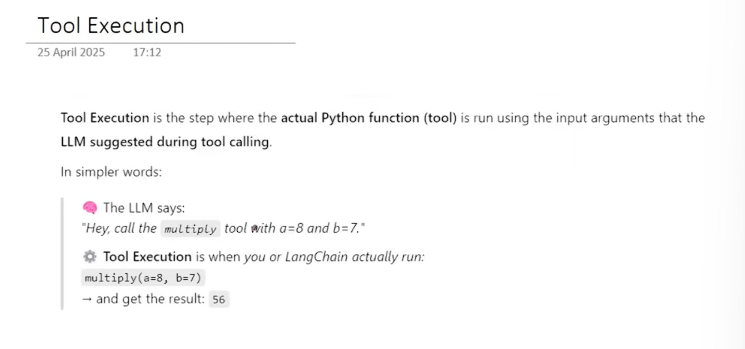

In [7]:
multiply.invoke(result.tool_calls[0])

ToolMessage(content='8', name='multiply', tool_call_id='call_OQSolOB8qaVy2LOCmMMdQFqP')

In [8]:
query = HumanMessage(content="What is the product of 5 and 6?")
messages = [query]
result = llm_with_tools.invoke(messages)

messages.append(result)

In [9]:
messages

[HumanMessage(content='What is the product of 5 and 6?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_mIrvnkpGwoCWKjdyajS97dvE', 'function': {'arguments': '{"a":5,"b":6}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 64, 'total_tokens': 81, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DDuCYfykyZAl8hsA4dUZclDJNUVxo', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--019c9fbf-d272-71e2-bd10-32454a33d02a-0', tool_calls=[{'name': 'multiply', 'args': {'a': 5, 'b': 6}, 'id': 'call_mIrvnkpGwoCWKjdyajS97dvE', 'type': 'tool_call'}], usage_metadata={'input_tokens'

In [10]:
tool_results = multiply.invoke(result.tool_calls[0])
tool_results

ToolMessage(content='30', name='multiply', tool_call_id='call_mIrvnkpGwoCWKjdyajS97dvE')

In [11]:
messages.append(tool_results)
messages

[HumanMessage(content='What is the product of 5 and 6?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_mIrvnkpGwoCWKjdyajS97dvE', 'function': {'arguments': '{"a":5,"b":6}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 64, 'total_tokens': 81, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DDuCYfykyZAl8hsA4dUZclDJNUVxo', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--019c9fbf-d272-71e2-bd10-32454a33d02a-0', tool_calls=[{'name': 'multiply', 'args': {'a': 5, 'b': 6}, 'id': 'call_mIrvnkpGwoCWKjdyajS97dvE', 'type': 'tool_call'}], usage_metadata={'input_tokens'

In [12]:
llm_with_tools.invoke(
    messages
).content

'The product of 5 and 6 is 30.'

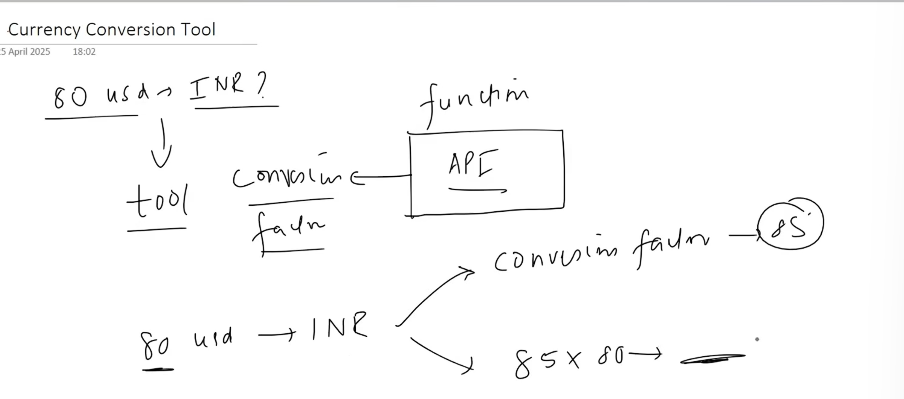

In [20]:
#currency exchange rate
from dotenv import load_dotenv
import os
from langchain_core.tools import InjectedToolArg #we will set the valus of this
from typing import Annotated
load_dotenv()
EXCHANGE_RATE_API = os.getenv("EXCHANGE_RATE_API")

@tool
def get_conversion_factor(
    base_currency: str, target_currency: str
) -> float:
    """
    Given a base currency and a target currency, returns the conversion factor from the base currency to the target currency.
    """
    url = f"https://v6.exchangerate-api.com/v6/{EXCHANGE_RATE_API}/pair/{base_currency}/{target_currency}"
    response = requests.get(url)
    return response.json()
@tool
def convert(
    base_currency: int, conversion_rate: Annotated[float, InjectedToolArg]
) -> float:
    """
    Given a base currency and a conversion rate, returns the converted amount in the target currency.
    """

    return float(conversion_rate * base_currency)


In [21]:
get_conversion_factor.invoke(
    {"base_currency": "USD", "target_currency": "INR"}
)
convert.invoke(
    {"base_currency": 100, "conversion_rate": 82.5}
)

8250.0

In [30]:
#tool binding
messages=[]
llm = ChatOpenAI()
llm_with_tools= llm.bind_tools([get_conversion_factor, convert])
messages = [HumanMessage(content="What is the conversion rate from USD to INR?, and based on that can you convert 100 USD to INR?")]
ai_message = llm_with_tools.invoke(messages)
messages.append(ai_message)
print(messages)
ai_message.tool_calls

[HumanMessage(content='What is the conversion rate from USD to INR?, and based on that can you convert 100 USD to INR?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_2hWZrFc84RMhfIkUSrgYNwhJ', 'function': {'arguments': '{"base_currency": "USD", "target_currency": "INR"}', 'name': 'get_conversion_factor'}, 'type': 'function'}, {'id': 'call_iru5KnqrxgGW5uIbSvRRldQb', 'function': {'arguments': '{"base_currency": 100}', 'name': 'convert'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 125, 'total_tokens': 176, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DDuVE0pKteOi3hMDFHnwRwsTOyBAx', 'service_tier': 'default', 'fi

[{'name': 'get_conversion_factor',
  'args': {'base_currency': 'USD', 'target_currency': 'INR'},
  'id': 'call_2hWZrFc84RMhfIkUSrgYNwhJ',
  'type': 'tool_call'},
 {'name': 'convert',
  'args': {'base_currency': 100},
  'id': 'call_iru5KnqrxgGW5uIbSvRRldQb',
  'type': 'tool_call'}]

In [31]:
import json
conversion_factor = None
converted_amount = None
# Now we can loop through the tool calls and invoke the appropriate tools based on the tool call name
for tool_call in ai_message.tool_calls:
    if tool_call['name'] == "get_conversion_factor":
        tool_mssg1 = get_conversion_factor.invoke(tool_call)
        conversion_factor = json.loads(tool_mssg1.content)["conversion_rate"]
        print(f"Conversion factor from USD to INR: {conversion_factor}")
        messages.append(tool_mssg1)
    elif tool_call['name'] == "convert":
        tool_call['args']['conversion_rate'] = conversion_factor  # Inject the conversion factor into the tool call arguments
        tool_mssg2 = convert.invoke(
            tool_call
        )
        messages.append(tool_mssg2)
        converted_amount = json.loads(tool_mssg2.content)
        print(f"Converted amount: {converted_amount} INR")


Conversion factor from USD to INR: 91.027
Converted amount: 9102.7 INR


In [32]:
messages

[HumanMessage(content='What is the conversion rate from USD to INR?, and based on that can you convert 100 USD to INR?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_2hWZrFc84RMhfIkUSrgYNwhJ', 'function': {'arguments': '{"base_currency": "USD", "target_currency": "INR"}', 'name': 'get_conversion_factor'}, 'type': 'function'}, {'id': 'call_iru5KnqrxgGW5uIbSvRRldQb', 'function': {'arguments': '{"base_currency": 100}', 'name': 'convert'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 125, 'total_tokens': 176, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DDuVE0pKteOi3hMDFHnwRwsTOyBAx', 'service_tier': 'default', 'f

In [33]:
llm_with_tools.invoke(
    messages
).content

'The conversion rate from USD to INR is 1 USD to 91.027 INR.\n\nBased on this conversion rate, 100 USD is equivalent to 9102.7 INR.'

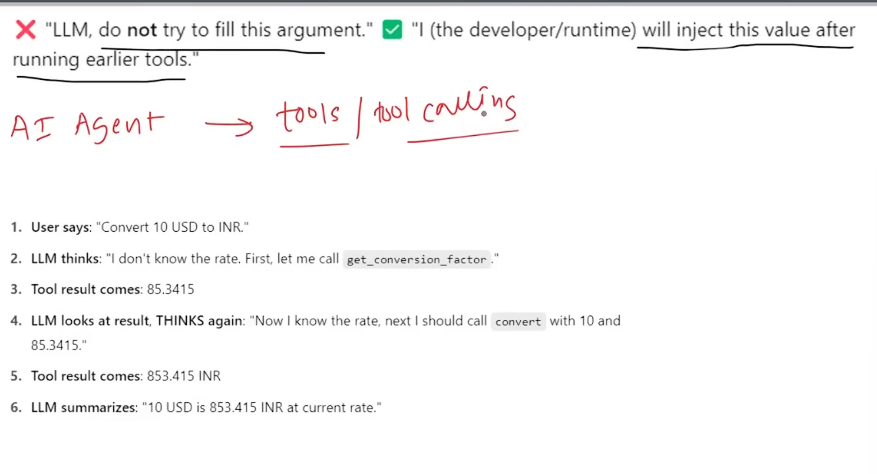

In [37]:
#currency exchange rate
from dotenv import load_dotenv
import os
from langchain_core.tools import InjectedToolArg #we will set the valus of this
from typing import Annotated
load_dotenv()
EXCHANGE_RATE_API = os.getenv("EXCHANGE_RATE_API")

@tool
def get_conversion_factor(
    base_currency: str, target_currency: str
) -> float:
    """
    Given a base currency and a target currency, returns the conversion factor from the base currency to the target currency.
    """
    url = f"https://v6.exchangerate-api.com/v6/{EXCHANGE_RATE_API}/pair/{base_currency}/{target_currency}"
    response = requests.get(url)
    return response.json()
@tool
def convert(
    base_currency: int, conversion_rate: Annotated[float, InjectedToolArg]
) -> float:
    """
    Given a base currency and a conversion rate, returns the converted amount in the target currency.
    """

    return float(conversion_rate * base_currency)


#tool binding
messages=[]
query = HumanMessage(content="What is the conversion rate from CAD to PKR?, and based on that can you convert 9000 CAD to PKR?")
messages.append(query)

llm = ChatOpenAI()
llm_with_tools= llm.bind_tools([get_conversion_factor, convert])

ai_message = llm_with_tools.invoke(messages)
messages.append(ai_message)
print(messages)



conversion_factor = None
converted_amount = None
# Now we can loop through the tool calls and invoke the appropriate tools based on the tool call name
for tool_call in ai_message.tool_calls:
    if tool_call['name'] == "get_conversion_factor":
        tool_mssg1 = get_conversion_factor.invoke(tool_call)
        conversion_factor = json.loads(tool_mssg1.content)["conversion_rate"]
        print(f"Conversion factor from USD to INR: {conversion_factor}")
        messages.append(tool_mssg1)
    elif tool_call['name'] == "convert":
        tool_call['args']['conversion_rate'] = conversion_factor  # Inject the conversion factor into the tool call arguments
        tool_mssg2 = convert.invoke(
            tool_call
        )
        messages.append(tool_mssg2)
        converted_amount = json.loads(tool_mssg2.content)
        print(f"Converted amount: {converted_amount} INR")

llm_with_tools.invoke(
    messages
).content

[HumanMessage(content='What is the conversion rate from CAD to PKR?, and based on that can you convert 9000 CAD to PKR?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_pn0CgHKo4aibIyS9J7ct1tEF', 'function': {'arguments': '{"base_currency": "CAD", "target_currency": "PKR"}', 'name': 'get_conversion_factor'}, 'type': 'function'}, {'id': 'call_Tjvtn64o985PQRwtEZ33Yu5g', 'function': {'arguments': '{"base_currency": 9000}', 'name': 'convert'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 126, 'total_tokens': 178, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DDucbaPm0Q6p7P4lvqviHX8j2Aul3', 'service_tier': 'default', '

'The conversion rate from CAD to PKR is 204.1111. \n\nConverting 9000 CAD to PKR using this rate gives us 1,836,999.9 PKR.'